# **Data Cleaning**

**Project**: Airbnb Market Segmentation Analysis \
**Goal**: Clean the listings and reviews dataset for future analysis.

### 1. Imports & environment setup

In [1]:
import pandas as pd
import numpy as np
import re
import html

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

### 2. Data Loading

In [3]:
listings_raw = pd.read_csv(BASE_PATH / "data" / "raw" / "listings.csv")
reviews_raw = pd.read_csv(BASE_PATH / "data" / "raw" / "reviews.csv")

#### 2.1 Listings dataframe

In [4]:
listings_raw.head(8)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2737,https://www.airbnb.com/rooms/2737,20250914152919,2025-09-15,city scrape,"Elif's room in cozy, clean flat.",10 min by bus you can get to Piazza Venezia or...,It used to be an industrial area until late 80...,https://a0.muscache.com/pictures/41225252/e955...,3047,...,5.00,4.40,4.40,NaN,f,6,0,6,0,0.04
1,11834,https://www.airbnb.com/rooms/11834,20250914152919,2025-09-15,city scrape,"Charming Boschetto Studio, Rome",Fantastic apartment in the Monti district. The...,"""Monti"" with its narrow cobblestone alleys, cr...",https://a0.muscache.com/pictures/miso/Hosting-...,44552,...,4.96,4.99,4.81,IT058091C29VJSIZQZ,f,1,1,0,0,1.62
2,12398,https://www.airbnb.com/rooms/12398,20250914152919,2025-09-15,city scrape,Casa Donatello - Home far from Home,Casa Donatello is a newly renovated two-bedroo...,You are at 15 minutes walking distance from hi...,https://a0.muscache.com/pictures/miso/Hosting-...,11756,...,5.00,4.89,4.83,it058091c2kv6epw8f,f,1,1,0,0,0.47
3,19965,https://www.airbnb.com/rooms/19965,20250914152919,2025-09-15,city scrape,S. Peter's Square 5 Min WALK bright and quite ...,AT ONLY 5 MINUTES WALK to S.Peter's Basilica S...,Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.90,4.90,4.54,IT058091C20YD35BX2,t,3,3,0,0,1.07
4,19967,https://www.airbnb.com/rooms/19967,20250914152919,2025-09-15,city scrape,*In front Vatican Museums 2 bedrooms quite bri...,"IN FRONT of the Vatican Museums entrance, at O...",Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.80,4.85,4.28,IT058091C20YD35BX2,t,3,3,0,0,0.32
5,20534,https://www.airbnb.com/rooms/20534,20250914152919,2025-09-15,city scrape,DormiRoma - Cedro 1 Apartment - Trastevere,Cedro 1 Apartment is located in a beautiful s...,"Trastevere, the heart of the city, home to maj...",https://a0.muscache.com/pictures/miso/Hosting-...,77540,...,4.79,4.92,4.27,IT058091B4I3RFDVLG,t,5,5,0,0,0.27
6,20587,https://www.airbnb.com/rooms/20587,20250914152919,2025-09-15,city scrape,DormiRoma - Cedro 4 Apartment - Trastevere,Cedro 4 Apartment is located in a beautiful se...,"Trastevere, the heart of the city, home to maj...",https://a0.muscache.com/pictures/miso/Hosting-...,77540,...,4.94,4.89,4.70,IT058091B4PUG96AR4,t,5,5,0,0,0.48
7,20699,https://www.airbnb.com/rooms/20699,20250914152919,2025-09-15,city scrape,Vintage Suite w/ Private Bath by Esquiline Suites,This bright and elegant Vintage Suite by Esqui...,The multi-ethnic neighborhood of Esquilino is ...,https://a0.muscache.com/pictures/31060743/8d30...,78287,...,4.95,4.55,4.77,IT058091C1AXWLCJ7C,t,8,2,6,0,3.89


In [5]:
listings_raw.shape

(37652, 79)

In [6]:
listings_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 37652 entries, 0 to 37651
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            37652 non-null  int64  
 1   listing_url                                   37652 non-null  str    
 2   scrape_id                                     37652 non-null  int64  
 3   last_scraped                                  37652 non-null  str    
 4   source                                        37652 non-null  str    
 5   name                                          37652 non-null  str    
 6   description                                   36703 non-null  str    
 7   neighborhood_overview                         17721 non-null  str    
 8   picture_url                                   37652 non-null  str    
 9   host_id                                       37652 non-null  int64  
 1

In [7]:
listings_raw.describe(include = 'all')

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.765200e+04,37652,3.765200e+04,37652,37652,37652,36703,17721,37652,3.765200e+04,...,32254.000000,32252.000000,32253.000000,34589,37652,37652.000000,37652.000000,37652.000000,37652.000000,32255.000000
unique,NaN,37652,NaN,2,2,36682,33713,15191,37344,NaN,...,NaN,NaN,NaN,26958,2,NaN,NaN,NaN,NaN,NaN
top,NaN,https://www.airbnb.com/rooms/2737,NaN,2025-09-15,city scrape,Appartamento,Relax in this peaceful and centrally-located p...,Located in the north of the city center Monti ...,https://a0.muscache.com/pictures/miso/Hosting-...,NaN,...,NaN,NaN,NaN,"I applied for a CIN, but haven’t received it yet",t,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,33064,33668,18,77,15,12,NaN,...,NaN,NaN,NaN,337,22855,NaN,NaN,NaN,NaN,NaN
mean,7.461415e+17,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.611336e+08,...,4.856055,4.753798,4.686264,NaN,NaN,9.467598,7.847657,1.527276,0.027701,1.744446
std,5.767852e+17,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2.432036e+08,...,0.299506,0.317206,0.361069,NaN,NaN,27.352151,27.028811,3.706959,0.540813,1.626930
min,2.737000e+03,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.353000e+03,...,1.000000,1.000000,1.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.892659e+07,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.960476e+07,...,4.830000,4.650000,4.600000,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.440000
50%,9.477797e+17,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,1.757405e+08,...,4.950000,4.840000,4.760000,NaN,NaN,2.000000,1.000000,0.000000,0.000000,1.260000
75%,1.269260e+18,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,5.014931e+08,...,5.000000,4.970000,4.890000,NaN,NaN,6.000000,3.000000,2.000000,0.000000,2.650000


#### 2.2 Reviews dataframe

In [8]:
reviews_raw.head(8)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2737,24343517,2014-12-26,24333039,Raphaell,"This spot was in a great and nice area,walking..."
1,2737,24966779,2015-01-04,10493776,Ia,"Elif was really very helpful, while arranging ..."
2,2737,29770086,2015-04-12,29630601,Julia,"Elif's flat is spacious, clean, and had everyt..."
3,2737,30477570,2015-04-22,31215535,Sevil,I had a wonderful time staying with Elif and h...
4,2737,31659336,2015-05-08,1959813,Suzy,"Elif was a brilliant host, with an exceptional..."
5,11834,246099,2011-05-01,346365,Joanne,We loved our stay at Boschetto House. It was a...
6,11834,343799,2011-06-30,388909,Eteri,Everything was perfect! The apartment in a per...
7,11834,529617,2011-09-13,953228,Ginger,Apartment: Very nicely set up for guests - wel...


In [9]:
reviews_raw.shape

(2193330, 6)

In [10]:
reviews_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2193330 entries, 0 to 2193329
Data columns (total 6 columns):
 #   Column         Dtype
---  ------         -----
 0   listing_id     int64
 1   id             int64
 2   date           str  
 3   reviewer_id    int64
 4   reviewer_name  str  
 5   comments       str  
dtypes: int64(3), str(3)
memory usage: 100.4 MB


In [11]:
reviews_raw.describe(include = 'all')

,listing_id,id,date,reviewer_id,reviewer_name,comments
count,2.193330e+06,2.193330e+06,2193330,2.193330e+06,2193326,2193194
unique,NaN,NaN,5242,NaN,210331,2128354
top,NaN,NaN,2025-06-15,NaN,David,.
freq,NaN,NaN,3059,NaN,12442,3364
mean,2.786899e+17,7.687826e+17,NaN,1.988914e+08,NaN,NaN
std,4.496493e+17,5.411816e+17,NaN,1.838539e+08,NaN,NaN
min,2.737000e+03,4.220600e+04,NaN,4.600000e+01,NaN,NaN
25%,9.950970e+06,5.757394e+08,NaN,4.574577e+07,NaN,NaN
50%,2.920817e+07,9.099389e+17,NaN,1.344782e+08,NaN,NaN
75%,6.590309e+17,1.238298e+18,NaN,3.235647e+08,NaN,NaN


##  3. Duplicates check

#### 3.1 Listings dataframe

In [12]:
# duplicated listings ids 
print(listings_raw.duplicated("id").sum())

# duplicated whole rows
print(listings_raw.duplicated(subset=listings_raw.columns.drop('id')).sum())

# duplicated listings names
print(listings_raw.duplicated("name").sum())

# duplicated listings descriptions
print(listings_raw.duplicated("description").sum())

# duplicated listing_urls
print(listings_raw.duplicated("listing_url").sum())

0
0
970
3938
0


In [13]:
# print rows with duplicated names
listings_raw[listings_raw.duplicated("name", keep = False)].sort_values(by = 'name')

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
24155,1147781118331143481,https://www.airbnb.com/rooms/1147781118331143481,20250914152919,2025-09-15,previous scrape,(Colosseo) Camera di lusso al centro di Roma,NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,484756313,...,5.00,4.88,4.88,IT058091B49GCHE6QW,t,6,0,6,0,0.51
24226,1150716406754631079,https://www.airbnb.com/rooms/1150716406754631079,20250914152919,2025-09-15,city scrape,(Colosseo) Camera di lusso al centro di Roma,The San Giovanni Retreat is a Luxury Guesthous...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,484756313,...,5.00,5.00,4.00,IT058091B49GCHE6QW,t,6,0,6,0,0.21
24219,1150660321577994956,https://www.airbnb.com/rooms/1150660321577994956,20250914152919,2025-09-15,city scrape,(Colosseo)Camera con balcone al centro di Roma,NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,484756313,...,5.00,5.00,4.50,IT058091B49GCHE6QW,t,6,0,6,0,0.13
24220,1150668316352949889,https://www.airbnb.com/rooms/1150668316352949889,20250914152919,2025-09-15,city scrape,(Colosseo)Camera con balcone al centro di Roma,The San Giovanni Retreat is a Luxury Guesthous...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,484756313,...,5.00,4.80,4.60,IT058091B49GCHE6QW,t,6,0,6,0,0.31
6506,23972978,https://www.airbnb.com/rooms/23972978,20250914152919,2025-09-15,city scrape,4321 Stazione Trastevere bed & breakfast,"Bright, quiet and panoramic apartment of 75 sq...","The neighborhood is popular, very 'Roman', fri...",https://a0.muscache.com/pictures/hosting/Hosti...,158506090,...,5.00,4.81,4.94,IT058091C12ULQTFXQ,f,3,1,2,0,0.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4727,15995943,https://www.airbnb.com/rooms/15995943,20250914152919,2025-09-15,previous scrape,stanza singola,The New Inn and a cozy guest house of Rome loc...,NaN,https://a0.muscache.com/pictures/836b19c9-441f...,88872950,...,4.81,4.75,4.58,IT058091B4MCJW7Q4U,t,11,1,8,0,2.21
892,1997075,https://www.airbnb.com/rooms/1997075,20250914152919,2025-09-15,city scrape,☆ BunkBeds BR in Beautiful Artsy APT in Traste...,Beautiful bright dorm in the heart of Rome. Th...,We believe Trastevere is simply the best part ...,https://a0.muscache.com/pictures/hosting/Hosti...,3305730,...,4.78,4.87,4.73,IT058091C2E3HLSEAS,f,7,0,7,0,3.63
895,2005424,https://www.airbnb.com/rooms/2005424,20250914152919,2025-09-15,previous scrape,☆ BunkBeds BR in Beautiful Artsy APT in Traste...,Beautiful bright dorm in the heart of Rome. Th...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3305730,...,4.80,4.85,4.72,IT058091C2E3HLSEAS,f,7,0,7,0,2.19
896,2005557,https://www.airbnb.com/rooms/2005557,20250914152919,2025-09-15,city scrape,☆ BunkBeds BR in Beautiful Artsy APT in Traste...,Beautiful bright dorm in the heart of Rome. Th...,We believe Trastevere is simply the best part ...,https://a0.muscache.com/pictures/hosting/Hosti...,3305730,...,4.81,4.87,4.75,IT058091C2E3HLSEAS,f,7,0,7,0,2.48


**Conclusion**: Even though some listing names and descriptions are duplicated, it does not mean that the listings refer to the same physical property. A single host can possess several properties with the same title, which may refer to different units within the same building. Prices may vary based on specific amenities or features, such as city views or floor level. Since no identical rows were found (excluding the unique ID), we can proceed with the analysis.

#### 3.2 Reviews dataframe

In [14]:
# duplicated comment
print(reviews_raw.duplicated('comments').sum())

# duplicated comments for partiqular listings ids
print(reviews_raw.duplicated(['listing_id','comments']).sum())

64975
1452


In [15]:
# view duplicated comments
reviews_raw[reviews_raw.duplicated("comments", keep = False)].sort_values(by = 'comments')

,listing_id,id,date,reviewer_id,reviewer_name,comments
257370,3446829,199107187,2017-10-01,69981910,Pau,.
349682,5297331,62518043,2016-02-15,51752286,Juan,.
1624183,640992868659241936,1152735845692063393,2024-05-09,249453719,Sarah,!
1827557,884688402475449300,1239803181613887675,2024-09-06,103533669,Pierre,!
1835508,897419810510791981,1123765304186802886,2024-03-30,460899803,Kateryna,!
...,...,...,...,...,...,...
2120730,1259335350242465155,1461599805210604078,2025-07-09,572947592,Darlington,NaN
2156906,1336019852433530500,1378178104705248661,2025-03-16,509000523,Charles,NaN
2157624,1336980407431866046,1490588503836212900,2025-08-18,208335382,James,NaN
2160226,1345123522749105483,1428910279458200707,2025-05-25,107648257,Paul,NaN


In [16]:
reviews_raw[reviews_raw.duplicated(['listing_id', "comments"], keep = False)].sort_values(by = 'comments')

,listing_id,id,date,reviewer_id,reviewer_name,comments
1759099,801921683624887852,1045579413446484915,2023-12-13,66657642,Dylan,-
276174,3994822,957840381003692861,2023-08-14,529489008,Faith,-
1390881,45792786,1099233624911459843,2024-02-25,472342198,Gianmarco,-
276143,3994822,297183359,2018-07-27,116093516,Lucija,-
1390904,45792786,1173847152422932680,2024-06-07,567765401,Oliver,-
...,...,...,...,...,...,...
794593,17006035,1111453535148747411,2024-03-13,433618651,Andre,👍🏻
1712737,747766187537708990,1144147468983625590,2024-04-27,526550533,Hakan,👍🏻👍🏻👍🏻
1712729,747766187537708990,1095500240565881418,2024-02-20,553031099,Chaewon,👍🏻👍🏻👍🏻
1028941,25768601,823012323182409076,2023-02-09,485190126,Julian,NaN


In [17]:
# delete duplicates by listing_id, reviewer_id and comments columns

reviews_deduped = reviews_raw.drop_duplicates(subset = ['listing_id', 'reviewer_id', 'comments'], keep = 'first')

print(len(reviews_deduped)/len(reviews_raw)* 100)

99.99220363556783


**Conclusion**: Technical duplicates were removed using a composite key: `listing_id`, `reviewer_id`, and `comments`. This approach ensures that we preserve unique feedback from different users while filtering out system glitches or double-posts. Additionally, a significant volume of "non-text" reviews (symbols, punctuation, and emoji) was identified. These entries require further preprocessing to determine their sentiment value during the NLP stage.

## 4. Structural Cleaning & Type Casting

### 4.1 Dropping irrelevant columns

#### 4.1.1 Listings dataframe

**Column Removal Rationale**

The following columns were identified as irrelevant for the current research objectives:

- `listing_url`, `scrape_id`, `source`: these contain internal scraping information and timestamps that do not characterize the property or influence pricing.

- `picture_url`, `host_url`, `host_name`, `host_thumbnail_url`, `host_picture_url`, `host_location`: visual content and URLs do not provide analytical value for segmentation and host identity is preserved via host_id.

- `neighbourhood`, `neighbourhood_group_cleansed`: `neighbourhood_cleansed` provides the most accurate and standardized location data for Rome and `neighbourhood_group_cleansed` is entirely empty in this dataset.

- `minimum_minimum_nights`, `maximum_minimum_nights`, `minimum_maximum_nights`,`maximum_maximum_nights`, `minimum_nights_avg_ntm`, `maximum_nights_avg_ntm`: these are seasonal variations of the base rules. They are highly correlated with the main minimum_nights column and introduce multi-collinearity and noise.

- `calendar_updated`, `has_availability`, `availability_30`, `availability_60`, `availability_eoy`: short-term availability fluctuates daily and is less indicative of long-term business strategy than availability_90 or availability_365.

- `number_of_reviews_ltm`, `number_of_reviews_l30d`, `number_of_reviews_ly`, `estimated_occupancy_l365d`, `estimated_revenue_l365d`: these are calculated using black-box formulas from Inside Airbnb. To ensure research integrity, we rely on raw metrics or perform our own calculations.

- `calculated_host_listings_count_entire_homes`, `calculated_host_listings_count_private_rooms`, `calculated_host_listings_count_shared_rooms`: the total count `calculated_host_listings_count` is sufficient for segmenting professional vs. amateur hosts.

In [18]:
# list of irrelevant columns

irr_cols_listings = ['listing_url', 'scrape_id', 'source', 'picture_url'
                    , 'host_url', 'host_name', 'host_thumbnail_url', 'host_picture_url', 'host_location'
                    , 'neighbourhood', 'neighbourhood_group_cleansed'
                    , 'minimum_minimum_nights', 'maximum_minimum_nights'
                    , 'minimum_maximum_nights', 'maximum_maximum_nights'
                    , 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm'
                    , 'calendar_updated'
                    , 'has_availability', 'availability_30', 'availability_60'
                    , 'calendar_last_scraped'
                    , 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'first_review'
                    , 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d'
                    , 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']

listings_cleaned = listings_raw.drop(irr_cols_listings, axis = 'columns')

#### 4.1.2 Reviews dataframe

In [19]:
# list of irrelevant columns

irr_cols_reviews = ['id', 'reviewer_name']

reviews_cleaned = reviews_deduped.drop(irr_cols_reviews, axis = 'columns')

### 4.2 Parsing Complex Data Structures

#### 4.2.1 Listings dataframe

- **Date columns** : `host_since`, `last_review`

In [20]:
# transfrom host_since variable from date to number of years

listings_cleaned['host_experience_years'] = ((pd.to_datetime(listings_cleaned['last_scraped']) - pd.to_datetime(listings_cleaned['host_since'])).dt.days / 365.25).round(1)

#transform last_review to number of days since last review
listings_cleaned['last_review_recency'] = ((pd.to_datetime(listings_cleaned['last_scraped']) - pd.to_datetime(listings_cleaned['last_review'])).dt.days).round(1)

listings_cleaned.drop(['host_since', 'last_review', 'last_scraped'], axis = 'columns', inplace = True)

- **% columns** : `host_response_rate`, `host_acceptance_rate`

In [21]:
# transform host_response_rate to float
listings_cleaned['host_response_rate'] = round(listings_cleaned['host_response_rate'].str.replace('%','').astype(float)/100, 2)

In [22]:
# transform host_acceptance_rate to float
listings_cleaned['host_acceptance_rate'] = round(listings_cleaned['host_acceptance_rate'].str.replace('%','').astype(float)/100, 2)

- **True-False columns** : `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `instant_bookable`

In [23]:
# transform host_is_superhost to 1-0 variable

listings_cleaned['host_is_superhost'] = listings_cleaned['host_is_superhost'].map({'t': 1, 'f' : 0})   

# transform host_has_profile_pic to 1-0 variable

listings_cleaned['host_has_profile_pic'] = listings_cleaned['host_has_profile_pic'].map({'t': 1, 'f' : 0}) 

# transform host_identity_verified to 1-0 variable

listings_cleaned['host_identity_verified'] = listings_cleaned['host_identity_verified'].map({'t': 1, 'f' : 0}) 

# transform instant_bookable to 1-0 variable

listings_cleaned['instant_bookable'] = listings_cleaned['instant_bookable'].map({'t': 1, 'f' : 0}) 

- **Price column** : `price`

In [24]:
# transform price to float

listings_cleaned['price'] = listings_cleaned['price'].str.replace(r'[$, ]', '', regex=True).astype(float)

- **Text to number columns** : `bathrooms_text`

In [25]:
# transform bathroom_text column

# 1. Create 1-0 variable if information whether bathroom is private is provided
listings_cleaned['bath_private_info'] = listings_cleaned['bathrooms_text'].str.contains('private', case = False, na = False).astype(int)

# 2. Create 1-0 variable if information whether bathroom is shared is provided
listings_cleaned['bath_shared_info'] = listings_cleaned['bathrooms_text'].str.contains('shared', case = False, na = False).astype(int)

# 3. Create new bathrooms_count column with number of baths from bathrooms_text column
listings_cleaned['bathroom_count'] = listings_cleaned['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)

# 4. In case information is provided as 'half-bath', fill 0.5 into the bathroom_count column
listings_cleaned.loc[
            listings_cleaned['bathrooms_text'].str.contains('half', case = False, na = False) 
            & listings_cleaned['bathroom_count'].isna(),
            'bathroom_count'
            ] = 0.5

# 5. Drop irrelevant columns
listings_cleaned.drop(['bathrooms_text', 'bathrooms'], axis = 'columns', inplace = True)

- **Text descriptive columns** : `name`, `description`, `neighborhood_overview`, `host_about`

In [26]:
# normalize text cols

text_cols = ['name', 'description', 'neighborhood_overview', 'host_about']

# 1. create a function for text columns normalization
def clean_text_light(x):

    if pd.isna(x) or str(x).strip() == "":

        return "unknown"

    x = str(x)

    # HTML decode
    x = html.unescape(x)

    # remove HTML tags
    x = re.sub(r'<.*?>', ' ', x)

    # remove emojis
    x = re.sub(
        "[\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U000024C2-\U0001F251]+",
        " ",
        x,
        flags=re.UNICODE
    )

    # normalize whitespace
    x = re.sub(r'\s+', ' ', x).strip()

    # replace texts like "-", ".", "..." etc with "unknown"
    if re.fullmatch(r'[\.\-\!\?…•·\s]+', x):
        return "unknown"
    
    return x.lower()

# 2. create cleaned columns
for col in text_cols:
    listings_cleaned[f'{col}_cleaned'] = listings_cleaned[col].apply(clean_text_light)

# 3. drop irrelvant columns
listings_cleaned.drop(text_cols, axis = 'columns', inplace = True)


- **Text column**: `license`

In [27]:
# 1. check the unique values (texts like 'IT...' are consifered as valid license category)
listings_cleaned[
    listings_cleaned['license'].notna() &
    ~listings_cleaned['license'].str.lower().str.startswith('it')
]['license'].unique()

<StringArray>
['I applied for a CIN, but haven’t received it yet', 'Exempt']
Length: 2, dtype: str

In [28]:
# 2. check number & % of unique values (texts like 'IT...' are consifered as valid license category)
license_summary = {
    'valid_license': listings_cleaned['license']
        .str.lower()
        .str.strip()
        .str.startswith('it')
        .fillna(False)
        .sum(),
    'pending': listings_cleaned['license']
        .eq('I applied for a CIN, but haven’t received it yet')
        .sum(),
    'exempt': listings_cleaned['license']
        .eq('Exempt')
        .sum(),
    'missing': listings_cleaned['license'].isna().sum()
}
license_summary = pd.Series(license_summary)
license_percent = (
    license_summary / len(listings_cleaned) * 100
).round(2)
pd.DataFrame({
    'count': license_summary,
    'percentage': license_percent
})

,count,percentage
valid_license,34173,90.76
pending,337,0.90
exempt,79,0.21
missing,3063,8.14


In [29]:
# 3. create a flag column for rows with missing values and pending license 
# meaning there is no information about the valid license for particular listing
# ("exempt" counts as valid license)

listings_cleaned['no_valid_license'] = np.where(
    listings_cleaned['license'].isna() |
    (listings_cleaned['license'] == 'I applied for a CIN, but haven’t received it yet'),
    1,
    0
)

# 4. drop raw 'license' column
listings_cleaned.drop('license', axis = 'columns', inplace = True)

- **List columns**: 

`host_verifications`

In [30]:
# unnest host_verifications variable

# 1. check all possible verifications
print(set(listings_cleaned['host_verifications'].str.replace(r"[\[\]' ]", "", regex=True).str.split(',').explode().dropna()))

# 2. replace [] with missing values
listings_cleaned['host_verifications'] = listings_cleaned['host_verifications'].replace('[]', np.nan)

# 3. create host_verifications_count column with the number of verifications
listings_cleaned['host_verifications_count'] = listings_cleaned['host_verifications'].str.count(',') + listings_cleaned['host_verifications'].notna().astype(int)

# 4. create host_verification_work_email 1-0 variable to signal if work email is provided.
# This variable may help to recognize the listings from agencies
listings_cleaned['host_verification_work_email'] = listings_cleaned['host_verifications'].str.contains('work_email', na = False).astype(int)

# 5. Drop column host_verifications
listings_cleaned.drop('host_verifications', axis = 'columns', inplace = True)

{'', 'work_email', 'phone', 'email'}


 `amenities`

The `amenities` column contained highly unstructured and noisy textual data, including a mix of real property features, promotional content, UI artifacts, and irrelevant metadata (e.g. service descriptions, brand names, days of the week, and formatting noise).

The entire transformation pipeline for the `amenities` column was designed with a specific analytical goal in mind:
**to identify which `amenities` have the strongest relationship with listing price and use them for market segmentation analysis**.

Rather than treating `amenities` as descriptive text, the objective was to extract price-relevant signals from this noisy feature and convert them into structured variables that can support segmentation.

This approach ensures that all subsequent steps are not purely technical transformations, but directly aligned with extracting maximum analytical value from a single high-dimensional text field.

1. Noise Removal

The raw `amenities` field was first standardized by:

* removing Unicode artifacts and non-ASCII characters
* converting all text to lowercase for consistency
* stripping brackets, quotes, and formatting symbols
* removing leading numeric or punctuation noise

After this, a custom set of junk patterns was applied to filter out irrelevant or non-informative entries such as:

* time-related strings (e.g. “every day”, weekdays)
* appliance descriptors without feature meaning (e.g. “wood-burning”, “stationary bike”)
* branding or cosmetic items (e.g. shampoo brands, cable services, streaming platforms)
* duplicate or malformed entries

Additionally, an `amenities_count` variable was created to capture the number of valid amenities per listing, serving as a proxy for overall property completeness.

In [31]:
# transform  the amenities column

# 1. create a list of junk patterns
junk_patterns = [
    r'^[\-\.\?]+\s|^\.\.|^\d+\s*years old|^and \d|^and (dresser|wardrobe|xbox|freezer)',
    r'^(monday|tuesday|wednesday|thursday|friday|saturday|sunday)',
    r'^\d+ days? a week|^\d+ day a week|^every day',
    r'^(open 24 hours|open specific hours|saltwater|olympic-sized|rooftop)',
    r'^(wood-burning|electric|heated|rowing|stationary bike|treadmill|workout bench|yoga mat|free weights)$',
    r'^(usb|voyage|airone|forno termoventilato|mill mill|salone monouso|piccoli saponi monouso)$',
    r'^(bio|neutro|neutro\.|bagnoschiuma|wella|nivea|samsung|sony|jvc|teac|ortigia|rytuals|viso)$',
    r'^(near|baking sheet|standard cable|premium cable|amazon prime video|disney\+|netflix|fire tv|hulu|hbo max|roku|chromecast|apple tv)$',
    r'^(in sala comune|in zona comune|in the (shared|common)|condiviso|frigo condviso)',
    r'^[\?\!\*]|^(nn|nd|na|xx|xxx|xxxx|x |b&v |hb )'
]

# 2. define function to remove junk patterns from the amenities column
def remove_junk_items(amenities_str):
    if not amenities_str:
        return ""
    items = [i.strip() for i in amenities_str.split(',')]
    clean_items = []
    
    for item in items:
        keep = True
        for pat in junk_patterns:
            if re.search(pat, item, re.IGNORECASE):
                keep = False
                break
        if keep and item:
            clean_items.append(item)
            
    return ", ".join(clean_items)

# 3. basic cleaning of the aenities column
listings_cleaned['amenities_cleaned'] = listings_cleaned['amenities'] \
    .str.replace(r'\\u[0-9a-fA-F]{4}', ' ', regex=True) \
    .str.encode('ascii', 'ignore').str.decode('ascii') \
    .str.lower() \
    .str.replace(r'[\[\]\"]', '', regex=True) \
    .str.replace(r'^[.\-\s\d]+', '', regex=True) \
    .str.strip()

# 4. remove junk patterns
listings_cleaned['amenities_cleaned'] = listings_cleaned['amenities_cleaned'].apply(remove_junk_items)

# 5. create the amenities_count column
listings_cleaned['amenities_count'] = listings_cleaned['amenities_cleaned'] \
    .fillna('') \
    .apply(lambda x: len([i.strip() for i in x.split(',') if i.strip()]))

2. Feature Mapping into Semantic Categories

To reduce dimensionality and improve interpretability, raw amenities were mapped into higher-level semantic tags using a rule-based dictionary (`amenity_map`).

These categories group similar features into meaningful clusters, such as:

* kitchen equipment (e.g. refrigerator, oven, coffee machine)
* climate control (air conditioning, heating, fans)
* digital amenities (WiFi, TV, streaming services)
* property features (balcony, view, workspace)
* luxury amenities (pool, hot tub, gym, sauna)
* safety and security features
* service-related offerings (housekeeping, host services)

This transformation significantly improves signal quality by reducing redundancy and noise in the feature space.

In [32]:
# 6. create the map to replace amenities with tags
amenity_map = {
    # kitchen
    'kitchen_basic': [
        r'kitchen',
        r'cooking basics',
        r'dishes and silverware',
        r'dining table',
        r'toaster',
        r'blender'
    ],
    'refrigerator': [
        r'refrigerator',
        r'fridge',
        r'frigo',
        r'minibar',
        r'frigobar'
    ],
    'oven_microwave': [
        r'oven',
        r'forno',
        r'microwave',
        r'microonde'
    ],
    'dishwasher': [
        r'dishwasher'
    ],
    'coffee_machine': [
        r'coffee maker',
        r'nespresso',
        r'espresso machine',
        r'moka',
        r'keurig',
        r'french press',
        r'pour-over coffee'
    ],
    # climate
    'air_conditioning': [
        r'air conditioning',
        r'window ac',
        r'portable air',
        r'ac - split',
        r'central air'
    ],
    'heating': [
        r'heating',
        r'riscaldamento',
        r'heated floors',
        r'central heating',
        r'radiant heating'
    ],
    'fans': [
        r'portable fans',
        r'ceiling fan'
    ],
    # internet / entertainment
    'wifi': [
        r'wifi',
        r'wi-fi',
        r'ethernet',
        r'internet'
    ],
    'tv': [
        r'tv',
        r'hdtv',
        r'\d+\s*inch'
    ],
    'streaming_services': [
        r'netflix',
        r'disney\+',
        r'hbo max',
        r'roku',
        r'chromecast',
        r'apple tv',
        r'fire tv',
        r'amazon prime video'
    ],
    'sound_system': [
        r'sound system',
        r'alexa',
        r'bluetooth'
    ],
    # laundry
    'washer': [
        r'washer',
        r'lavatrice'
    ],
    'dryer': [
        r'dryer',
        r'asciugatrice'
    ],
    # bathroom
    'hair_dryer': [
        r'hair dryer'
    ],
    'bathtub': [
        r'bathtub'
    ],
    'toiletries': [
        r'shampoo',
        r'soap',
        r'shower gel',
        r'bagnoschiuma',
        r'conditioner'
    ],
    'hot_water': [
        r'hot water'
    ],
    # basic amenities
    'basics': [
        r'essentials',
        r'bed linens',
        r'extra pillows and blankets',
        r'hangers',
        r'iron',
        r'clothing storage'
    ],
    # property / outdoor
    'balcony_outdoor': [
        r'patio',
        r'balcony',
        r'outdoor dining area',
        r'outdoor furniture',
        r'backyard',
        r'garden'
    ],
    'workspace': [
        r'dedicated workspace'
    ],
    'building_features': [
        r'elevator',
        r'building staff'
    ],
    'private_space': [
        r'private living room',
        r'private entrance',
        r'lock on bedroom door',
        r'single level home'
    ],
    'view': [
        r'view',
        r'waterfront',
        r'beachfront',
        r'city skyline',
        r'mountain view',
        r'lake view',
        r'sea view',
        r'river view'
    ],
    # parking
    'free_parking': [
        r'free parking',
        r'free street parking',
        r'free driveway parking'
    ],
    'paid_parking': [
        r'paid parking'
    ],
    # family
    'family_friendly': [
        r'crib',
        r'high chair',
        r'baby bath',
        r'children',
        r'pack.?n.?play'
    ],
    # pets / rules
    'pets_allowed': [
        r'pets allowed'
    ],
    'smoking_allowed': [
        r'smoking allowed'
    ],
    # luxury
    'pool_private': [
        r'private.*pool'
    ],
    'pool_shared': [
        r'shared.*pool',
        r'pool -',
        r'pool view'
    ],
    'hot_tub': [
        r'hot tub'
    ],
    'gym': [
        r'gym',
        r'fitness',
        r'exercise equipment',
        r'palestra'
    ],
    'spa_sauna': [
        r'sauna',
        r'spa'
    ],
    'bbq': [
        r'bbq',
        r'grill'
    ],
    'fireplace': [
        r'fireplace'
    ],
    'outdoor_leisure': [
        r'outdoor shower',
        r'fire pit',
        r'hammock',
        r'sun loungers'
    ],
    # safety
    'self_checkin': [
        r'self check-in',
        r'smart lock',
        r'keypad',
        r'lockbox'
    ],
    'security_features': [
        r'alarm',
        r'fire extinguisher',
        r'first aid',
        r'smoke alarm',
        r'carbon monoxide alarm'
    ],
    'property_monitoring': [
        r'exterior security cameras',
        r'noise decibel monitors',
        r'window guards'
    ],
    # services / convenience
    'housekeeping_paid': [
        r'housekeeping.*extra cost'
    ],
    'housekeeping_included': [
        r'housekeeping available(?!.*extra cost)'
    ],
    'breakfast': [
        r'breakfast'
    ],
    'host_services': [
        r'host greets you',
        r'luggage dropoff allowed'
    ],
    'travel_friendly': [
        r'long term stays allowed',
        r'laundromat nearby'
    ]
}

# 7. define the function for mapping
def clean_to_tags(raw_string):
    if pd.isna(raw_string) or raw_string == '':
        return []
    items = [i.strip().lower() for i in str(raw_string).split(',') if i.strip()]
    tags = set()
    for item in items:
        for tag, patterns in amenity_map.items():
            for pat in patterns:
                if re.search(pat, item):
                    tags.add(tag)
                    break
    return list(tags)

# 8. create the amenities_tags column
listings_cleaned['amenities_tags'] = listings_cleaned['amenities_cleaned'].apply(clean_to_tags)

3. Feature Matrix & Correlation Analysis

To analyze the relationship between `amenities` and `price`, a binary feature matrix was created from `amenities_tags`, where each unique amenity becomes a separate 0-1 indicator variable.

The resulting dataset (`amenities_df`) combines:

* price
* one-hot encoded amenity features

In [33]:
# 9. create the amenities_df with 1-0 columns for every tag in amenities_tags column
amenities_df = pd.concat(
    [
        listings_cleaned[['price']],
        listings_cleaned['amenities_tags']
            .apply(lambda x: ', '.join(x) if isinstance(x, list) else '')
            .str.get_dummies(sep=', ')
    ],
    axis=1
)

# 10. calculate the correlations between every tag and the price and display top 20
(amenities_df.corr(numeric_only=True)['price']
 .drop('price')
 .sort_values(key=abs, ascending=False)
 .head(20)
 .mul(100)
 .round(2))

pool_private        10.21
dishwasher           6.60
fireplace            5.33
free_parking        -4.89
family_friendly      4.70
bbq                  4.32
hot_water           -4.20
tv                   3.83
hot_tub              3.58
host_services       -3.13
travel_friendly     -2.96
coffee_machine       2.81
air_conditioning     2.69
smoking_allowed     -2.51
washer               2.27
toiletries          -2.12
wifi                 2.11
fans                -2.04
sound_system         1.99
bathtub              1.88
Name: price, dtype: float64

4. Premium Amenities Feature Selection & Encoding

Based on the previous correlation analysis, the top-performing amenities in terms of association with price were reviewed and manually selected for further feature engineering.

The final set of premium amenities was defined as:

* `pool_private`
* `dishwasher`
* `fireplace`
* `family_friendly`
* `hot_tub`

These features were chosen because they  showed the strongest relationship with price levels, while also representing meaningful and interpretable aspects of property quality (luxury, convenience, and family suitability). 

In [34]:
# 11. create a list of top amenities
premium_amenities = ['pool_private', 'dishwasher', 'fireplace', 'family_friendly', 'hot_tub']

5. Feature Engineering

From this subset, 2 types of variables were created:

- Aggregated luxury indicator
    * `has_top5_amenity`: equals 1 if a listing contains at least one premium amenity, otherwise 0
- Individual premium amenity flags
    * `has_pool_private`
    * `has_dishwasher`
    * `has_fireplace`
    * `has_family_friendly`
    * `has_hot_tub`

In [35]:
# 12. create a 1-0 column for listings that have at least 1 of the top amenities
listings_cleaned['has_top5_amenity'] = listings_cleaned['amenities_tags'].apply(
    lambda x: int(any(tag in x for tag in premium_amenities))
)

# 13. create 5 1-0 columns for every amenity from the top amenities
for amenity in premium_amenities:
    listings_cleaned[f'has_{amenity}'] = listings_cleaned['amenities_tags'].apply(
        lambda x: int(amenity in x)
    )

# 14. drop irrelevant columns
listings_cleaned.drop(['amenities', 'amenities_cleaned'], axis = 'columns', inplace = True)

- Final check of the structure

In [36]:
listings_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 37652 entries, 0 to 37651
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              37652 non-null  int64  
 1   host_id                         37652 non-null  int64  
 2   host_response_time              30861 non-null  str    
 3   host_response_rate              30861 non-null  float64
 4   host_acceptance_rate            33814 non-null  float64
 5   host_is_superhost               35456 non-null  float64
 6   host_neighbourhood              12241 non-null  str    
 7   host_listings_count             37643 non-null  float64
 8   host_total_listings_count       37643 non-null  float64
 9   host_has_profile_pic            37643 non-null  float64
 10  host_identity_verified          37643 non-null  float64
 11  neighbourhood_cleansed          37652 non-null  str    
 12  latitude                        37652 non-n

#### 4.2.2 Reviews dataframe

- **Text column** : `comments`

In [37]:
# 1. create function for the light comments cleaning v2
def clean_text_light_v2(x):
    if pd.isna(x) or str(x).strip() == "":
        return "unknown"

    x = str(x)

    # decode HTML entities
    x = html.unescape(x)

    # remove HTML tags only
    x = re.sub(r'<.*?>', ' ', x)

    # normalize whitespace
    x = re.sub(r'\s+', ' ', x).strip()

    # replace only true "garbage" strings with "unknown"
    if re.fullmatch(r'[\.\-•·\+\*]*', x):
        return "unknown"

    return x.lower()

# 2. clean the comments column
reviews_cleaned['comments_clean'] = reviews_cleaned['comments'].apply(clean_text_light_v2)

# 3. drop irrelevant column
reviews_cleaned.drop('comments', axis = 'columns', inplace = True)

### 4.3 Type casting

#### 4.3.1 Listings dataframe

In [38]:
# float column to nullable int
cols_float_to_nullable = [
    'host_is_superhost'
    ,'host_has_profile_pic'
    ,'host_identity_verified'
]

for col in cols_float_to_nullable:
    listings_cleaned[col] = listings_cleaned[col].astype('Int64')

# string columns to categories

cols_str_to_cat = [
    'host_response_time'
    ,'host_neighbourhood'
    ,'neighbourhood_cleansed'
    ,'property_type'
    ,'room_type'
]

for col in cols_str_to_cat:
    listings_cleaned[col] = listings_cleaned[col].astype('category')

listings_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 37652 entries, 0 to 37651
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              37652 non-null  int64   
 1   host_id                         37652 non-null  int64   
 2   host_response_time              30861 non-null  category
 3   host_response_rate              30861 non-null  float64 
 4   host_acceptance_rate            33814 non-null  float64 
 5   host_is_superhost               35456 non-null  Int64   
 6   host_neighbourhood              12241 non-null  category
 7   host_listings_count             37643 non-null  float64 
 8   host_total_listings_count       37643 non-null  float64 
 9   host_has_profile_pic            37643 non-null  Int64   
 10  host_identity_verified          37643 non-null  Int64   
 11  neighbourhood_cleansed          37652 non-null  category
 12  latitude                     

#### 4.3.2 Reviews dataframe

In [39]:
# date column to datetime format

reviews_cleaned['date'] = pd.to_datetime(reviews_cleaned['date'])

reviews_cleaned.info()

<class 'pandas.DataFrame'>
Index: 2193159 entries, 0 to 2193329
Data columns (total 4 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[us]
 2   reviewer_id     int64         
 3   comments_clean  str           
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 83.7 MB


## 5. Data Profiling

This section provides a high-level overview of the cleaned datasets after structural preprocessing and type standardization.

### 5.1 Listings dataframe

#### 5.1.1 Numerical columns

In [40]:
numeric_cols = ['host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count'
                , 'accommodates', 'bedrooms', 'beds', 'bathroom_count', 'price'
                , 'minimum_nights', 'maximum_nights', 'availability_90', 'availability_365'
                , 'number_of_reviews'
                , 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness' ,'review_scores_checkin'
                , 'review_scores_communication', 'review_scores_location', 'review_scores_value'
                , 'calculated_host_listings_count', 'reviews_per_month'
                , 'host_experience_years', 'last_review_recency', 'host_verifications_count', 'amenities_count']

- Stats overview

In [41]:
listings_cleaned[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
host_response_rate,30861.0,0.965777,0.139221,0.00,1.00,1.00,1.00,1.00
host_acceptance_rate,33814.0,0.924862,0.205377,0.00,0.98,1.00,1.00,1.00
host_listings_count,37643.0,16.116542,67.549298,1.00,1.00,3.00,7.00,1500.00
host_total_listings_count,37643.0,24.237999,130.416357,1.00,1.00,3.00,9.00,8768.00
accommodates,37652.0,3.820780,1.991687,1.00,2.00,4.00,5.00,16.00
bedrooms,36804.0,1.508640,0.896519,0.00,1.00,1.00,2.00,28.00
beds,33638.0,2.215590,1.469154,0.00,1.00,2.00,3.00,40.00
bathroom_count,37618.0,1.306582,0.691390,0.00,1.00,1.00,1.50,24.00
price,33564.0,197.328000,443.190521,8.00,93.00,133.00,195.25,10515.00
minimum_nights,37652.0,5.389939,16.623835,1.00,1.00,2.00,3.00,730.00


- Host behaviour columns

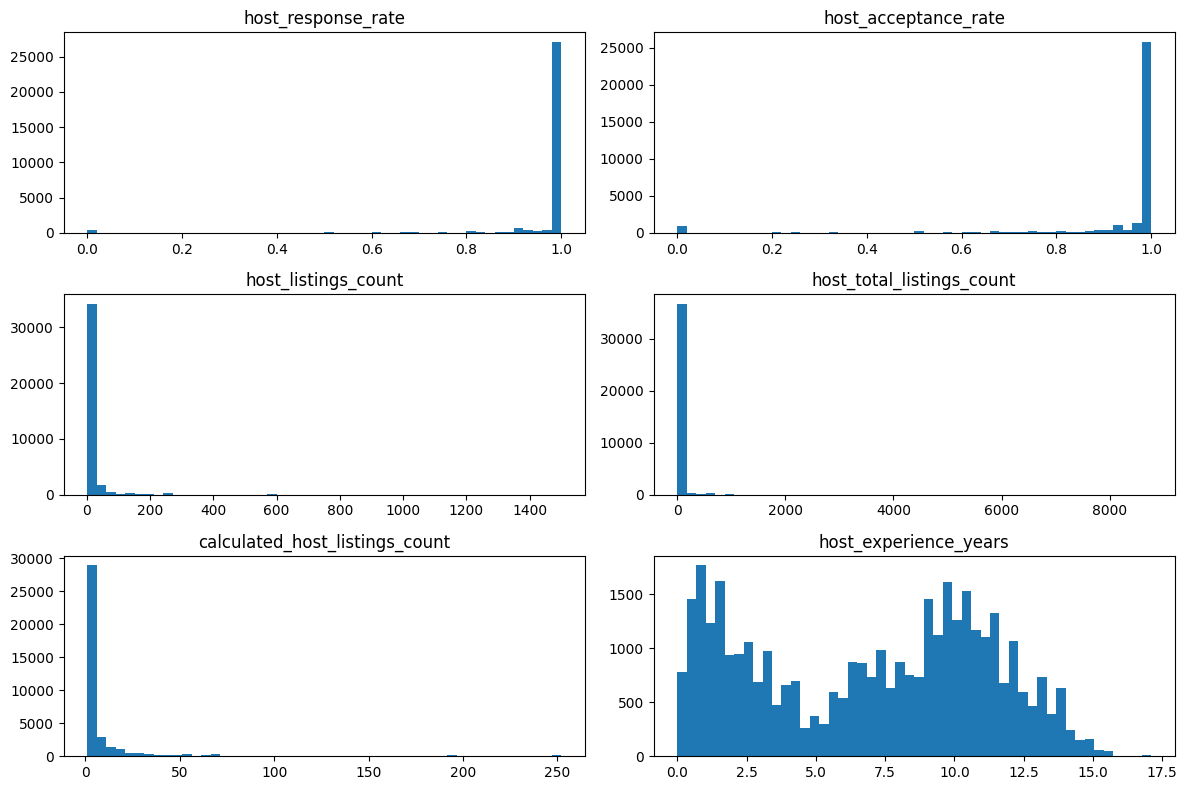

In [42]:
host_behaviour_cols = ['host_response_rate'
                       , 'host_acceptance_rate'
                       , 'host_listings_count'
                       , 'host_total_listings_count'
                       , 'calculated_host_listings_count'
                       , 'host_experience_years']

# histograms
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(host_behaviour_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=50)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Observations:**

- **`host_response_rate` & `host_acceptance_rate`**: Both are heavily left-skewed with a massive spike at 1.0 (100%), indicating that the majority of hosts respond and accept almost always. This ceiling effect suggests low discriminative power for segmentation. At the Feature Engineering stage, binarizing (e.g., "responsive host": response_rate > 0.9) or treating as a flag rather than continuous variable should be .

- **`host_listings_count` & `host_total_listings_count`**, **`calculated_host_listings_count`**: Strongly right-skewed with a long tail. Most hosts manage 1-10 listings, but a small number of professional hosts manage hundreds. This also may be an anomaly and a severe outlier, which will be investigated further. This distribution is a signal for host type segmentation (casual vs. professional/commercial host). May require transformation (e.g., log scaling) before clustering due to heavy skewness.. At the Feature Engineering stage, creating a categorical variable (e.g., solo host / small operator / commercial operator) should be considered.

- **`host_experience_years`**: Values range from 0 to 17 years, suggesting a mix of relatively new and long-established hosts. May be a useful feature for distinguishing established vs. newer listings. This variable potentially should be discretized into experience buckets at Feature Engineering stage.

- Property variables

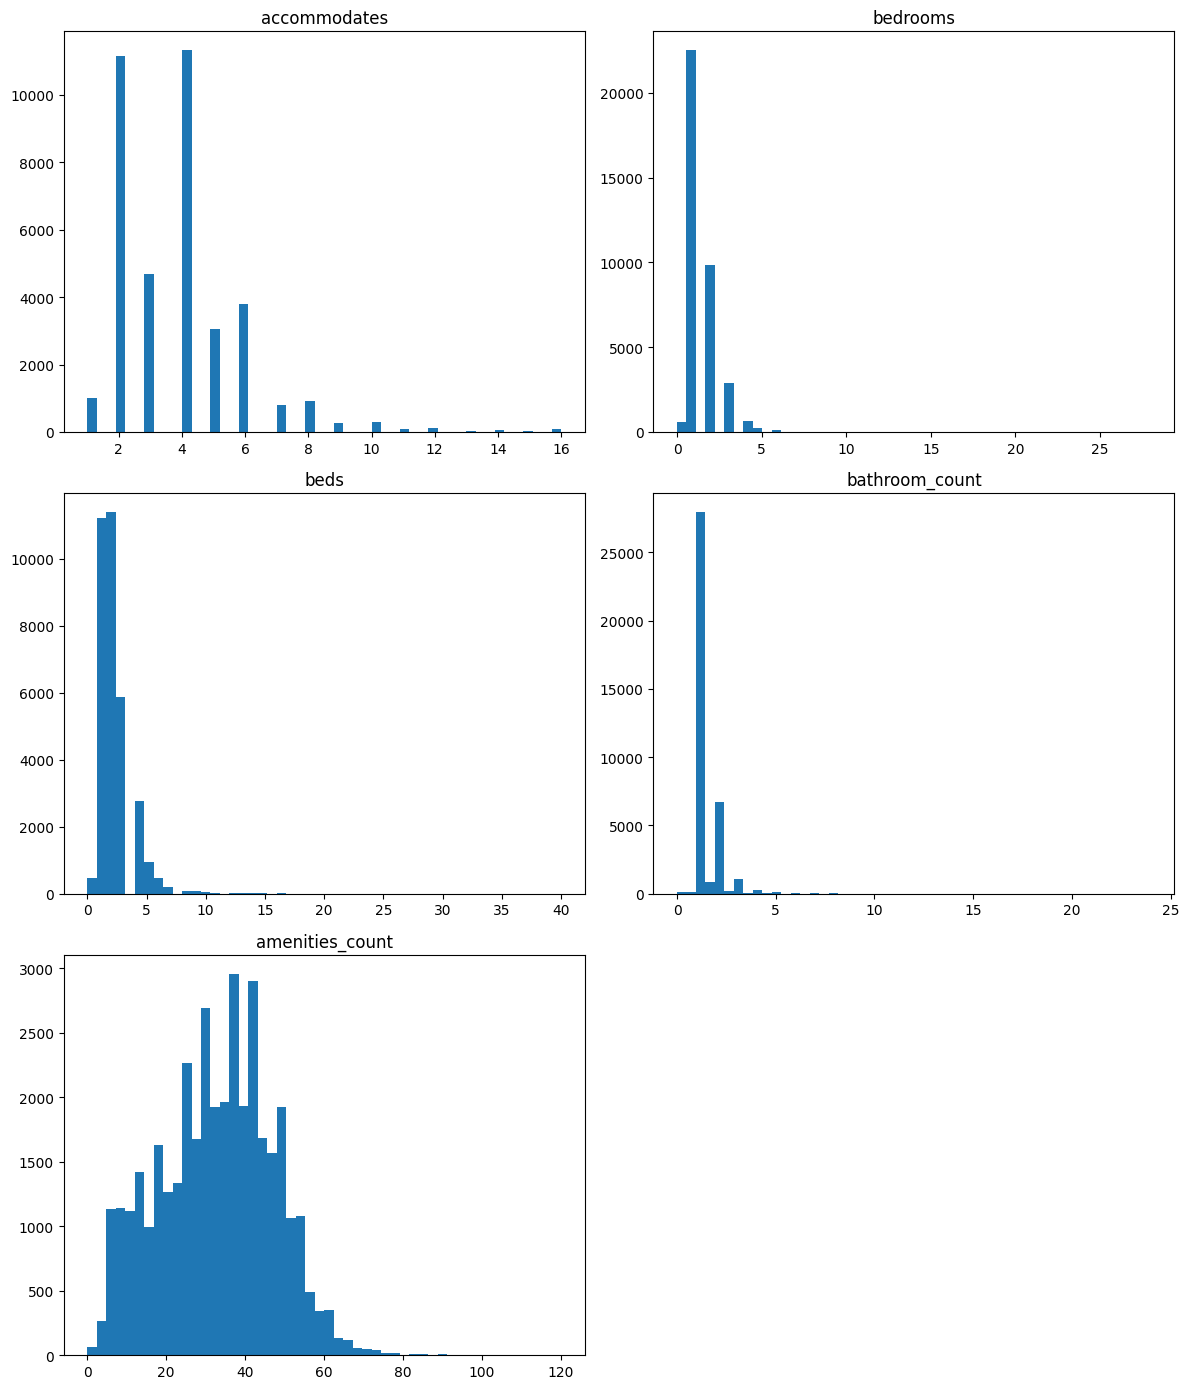

In [43]:
property_cols = ['accommodates'
                 , 'bedrooms'
                 , 'beds'
                 , 'bathroom_count'
                 , 'amenities_count']

# histograms
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()
for i, col in enumerate(property_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=50)
    axes[i].set_title(col)
    
axes[-1].axis('off')

plt.tight_layout()
plt.show()

**Observations:**

- **`accommodates`**: Right-skewed with most listings accommodating 2–5 guests. Tail extends to 16, indicating some large group/villa-type properties. Could be binned into capacity tiers (e.g. solo/couple, small group, large group) at the Feature Engineering stage.

- **`bedrooms`**: Right-skewed, majority are 1- or 2-bedroom listings. A small number of large properties with many bedrooms will likely be outliers. 

- **`beds`**: Similar pattern to `accommodates`. Right-skewed, potentially high correlated with `accommodates`.

- **`bathroom_count`**: Right-skewed, mostly 1–2 bathrooms. Outliers (e.g., 24 bathrooms) are likely caused by system errors or human factor.

- **`amenities_count`**: Approximately bell-shaped with mild right skewness and several high-end outliers, should be investigated and standardized.

- Price column

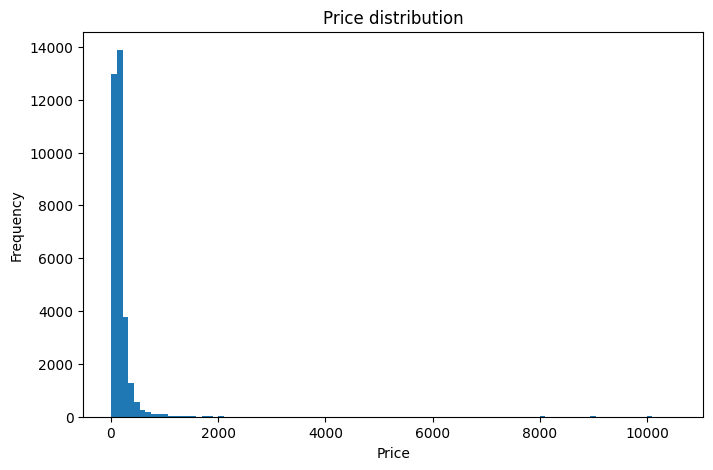

In [44]:
plt.figure(figsize=(8,5))
plt.hist(listings_cleaned['price'].dropna(), bins=100)
plt.title('Price distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**Observations:**

**`price`**: Extremely right-skewed with a long tail. Most listings are concentrated in the lower price range, but extreme outliers exist. Those may be luxury villas, etc., which might be a separate cluster.

- Availability & booking constraints

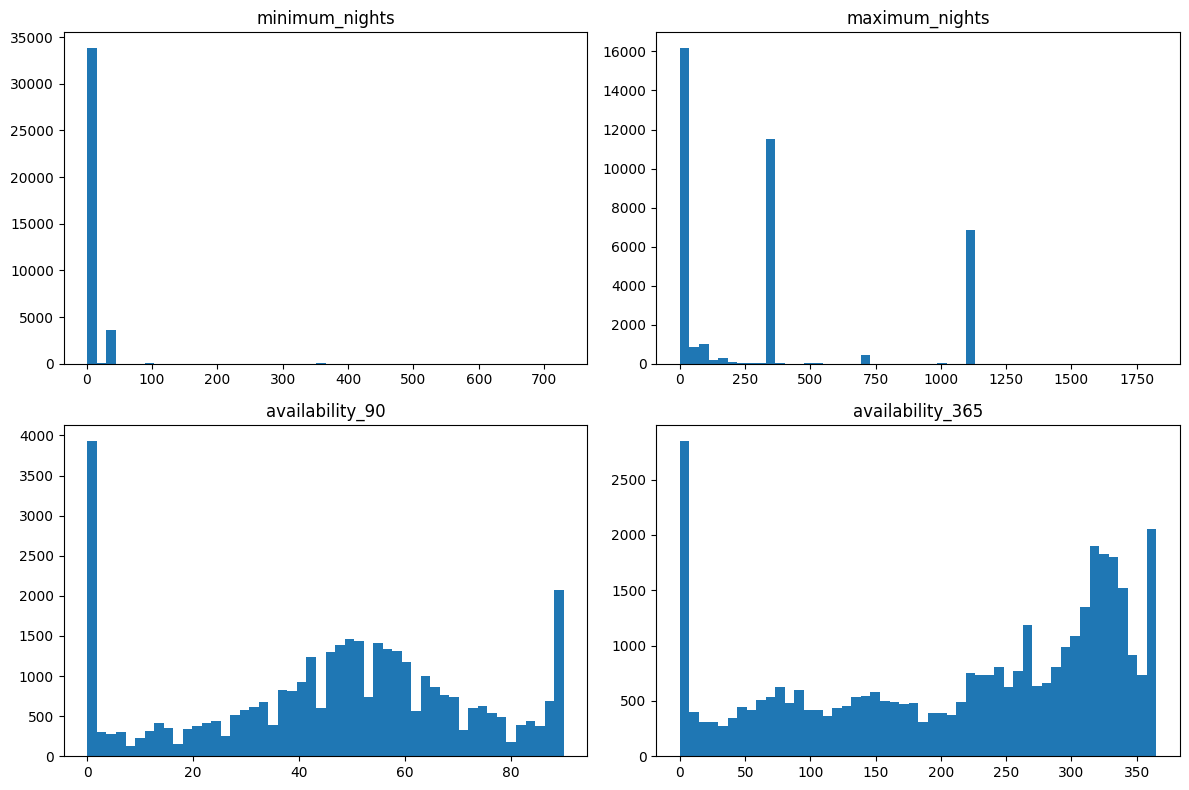

In [45]:
availability_cols = ['minimum_nights'
                      , 'maximum_nights'
                      , 'availability_90'
                      , 'availability_365']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(availability_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=50)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Observations:**

- **`minimum_nights`**: Extremely right-skewed — most listings require 1–3 nights minimum, but extreme values (up to 730 nights) indicate long-term rental listings mixed into the dataset. This is an important segmentation signal: short-term tourist rentals vs. long-term housing. Capping at FE stage or creating a binary flag for long-term rentals should be considered at further stages.

- **`maximum_nights`**: Shows a bimodal-like distribution. The ~365-day spike may reflect a platform default rather than true host intent. Similar to `minimum_nights`, this helps distinguish short-term vs. long-term rental strategies. May benefit from discretization.

- **`availability_90`**: Shows a multimodal distribution with clear peaks near 0 and 90 days, suggesting different booking and availability patterns across listings.

- **`availability_365`**: Shows a multimodal distribution with peaks near 0 and 365 days, indicating distinct listing availability patterns ranging from highly occupied or blocked calendars to nearly fully available listings.

- Demand columns

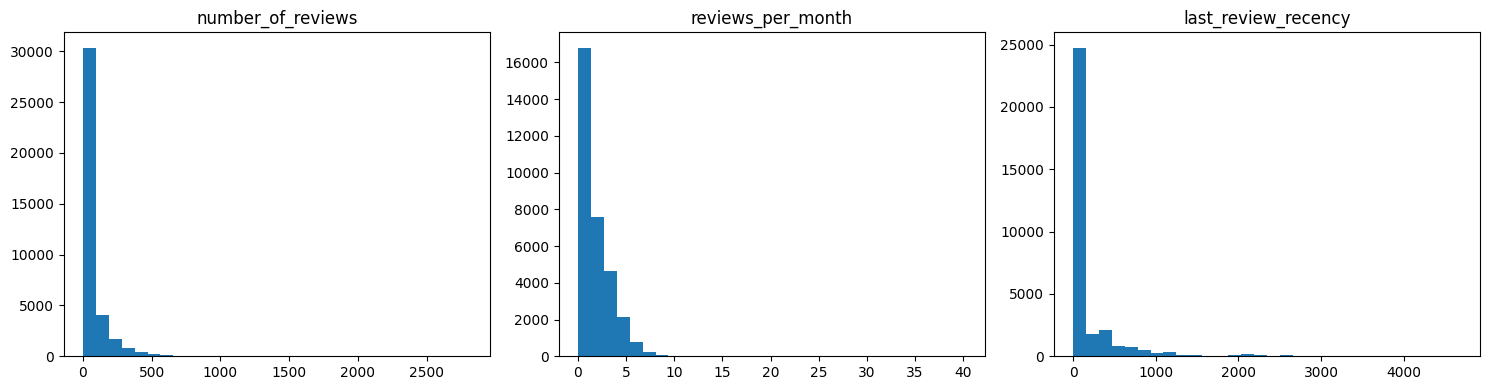

In [46]:
demand_cols = ['number_of_reviews', 'reviews_per_month', 'last_review_recency']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(demand_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Observations:**

- **`number_of_reviews`**: Heavily right-skewed, with a long tail of highly-reviewed listings. Acts as a proxy for listing popularity. Log transformation should be considered at FE stage. Listings with 0 reviews may require separate treatment, as they can represent newly listed, inactive, or low-demand properties.

- **`reviews_per_month`**: Right-skewed, concentrated near 0–3. Extreme values (up to 40) should be investigated during the Outliers Detection stage. This is a strong demand signal. 

- **`last_review_recency`**: Extremely right-skewed — most listings were reviewed recently, but a long tail extends to 4000 days (~13 years), which indicates inactive listings in the dataset. A binary "active listing" flag may be created as a derived feature

- Guest experience columns

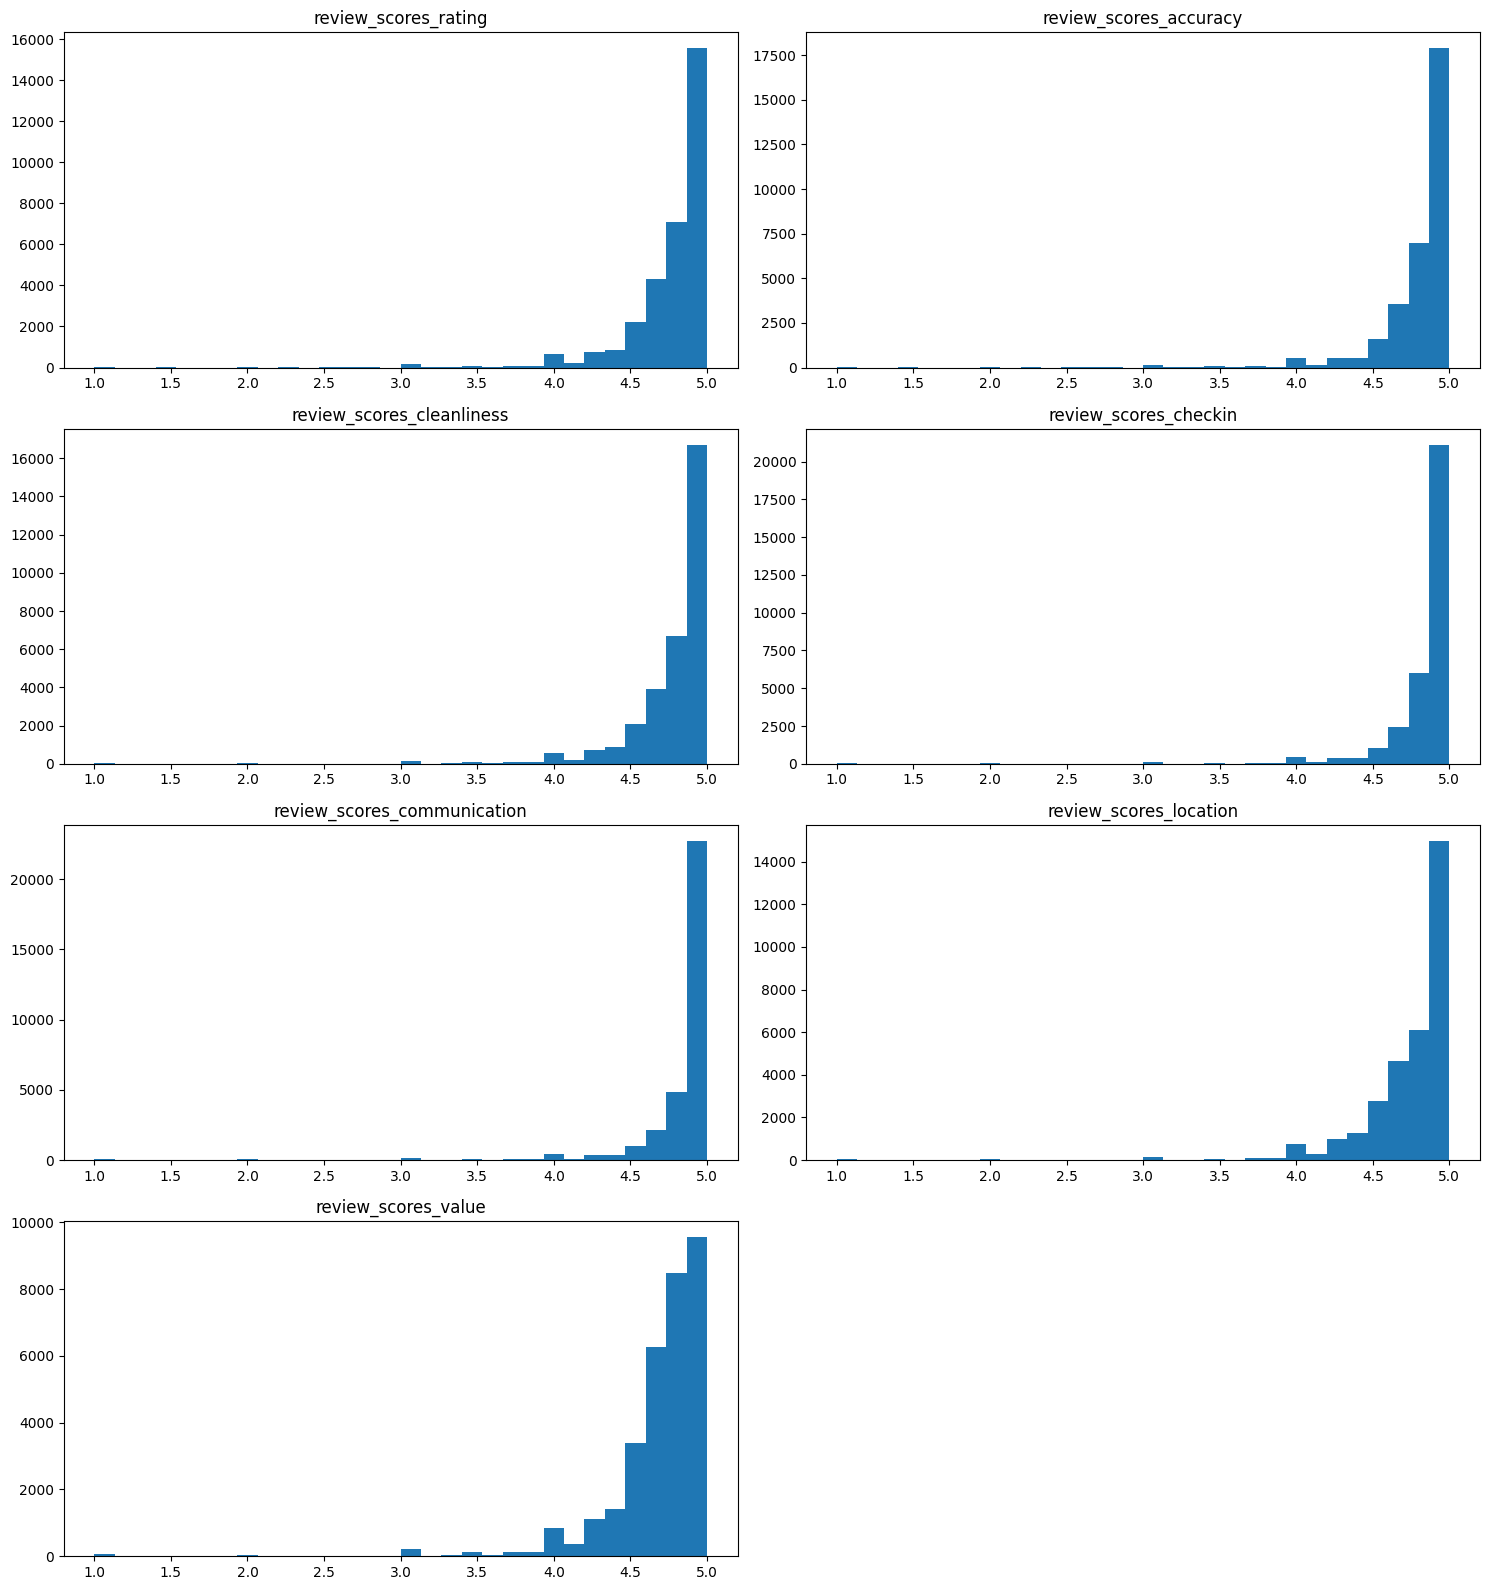

In [47]:
review_cols = ['review_scores_rating'
               , 'review_scores_accuracy'
               , 'review_scores_cleanliness'
               , 'review_scores_checkin'
               , 'review_scores_communication'
               , 'review_scores_location'
               , 'review_scores_value']

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()
for i, col in enumerate(review_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=30)
    axes[i].set_title(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Observations:**

- **All review score dimensions** (`rating`, `accuracy`, `cleanliness`, `checkin`, 
  `communication`, `location`, `value`): All are heavily left-skewed with a strong ceiling effect as distributions are clustered near 4.5–5.0 with a sharp drop toward lower values. 

- The low discriminative range means these variables may have limited power in separating clusters when used raw. 
  At the Feature engineering stage, those columns can be transformed by:
    - Computing a **composite review score** as weighted average.
    - Creating binary flags for "high performer" listings.

- `review_scores_value` has a slightly wider spread than others, suggesting guests are more willing to differentiate on perceived value, making it potentially more informative for future analysis.

### 5.1.2 Binary columns

In [48]:
bin_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified'
            , 'host_verification_work_email', 'no_valid_license'
            , 'instant_bookable'
            , 'bath_private_info', 'bath_shared_info', 'has_top5_amenity', 'has_pool_private', 'has_dishwasher'
            , 'has_fireplace', 'has_family_friendly', 'has_hot_tub'
            ]

- Stats overview

In [49]:
binary_stats = pd.DataFrame({
    'count_1': listings_cleaned[bin_cols].sum(),
    'count_0': listings_cleaned[bin_cols].shape[0] - listings_cleaned[bin_cols].sum(),
    'pct_1': (listings_cleaned[bin_cols].mean() * 100).round(2),
    'pct_0': (100 - listings_cleaned[bin_cols].mean() * 100).round(2)
})

binary_stats.sort_values('pct_1', ascending=False)

,count_1,count_0,pct_1,pct_0
host_has_profile_pic,35445,2207,94.16,5.84
host_identity_verified,34564,3088,91.82,8.18
instant_bookable,22855,14797,60.7,39.3
has_top5_amenity,20815,16837,55.28,44.72
host_is_superhost,13722,23930,38.7,61.3
has_family_friendly,14108,23544,37.47,62.53
has_dishwasher,12244,25408,32.52,67.48
bath_private_info,6289,31363,16.7,83.3
no_valid_license,3400,34252,9.03,90.97
host_verification_work_email,2742,34910,7.28,92.72


- Host information columns

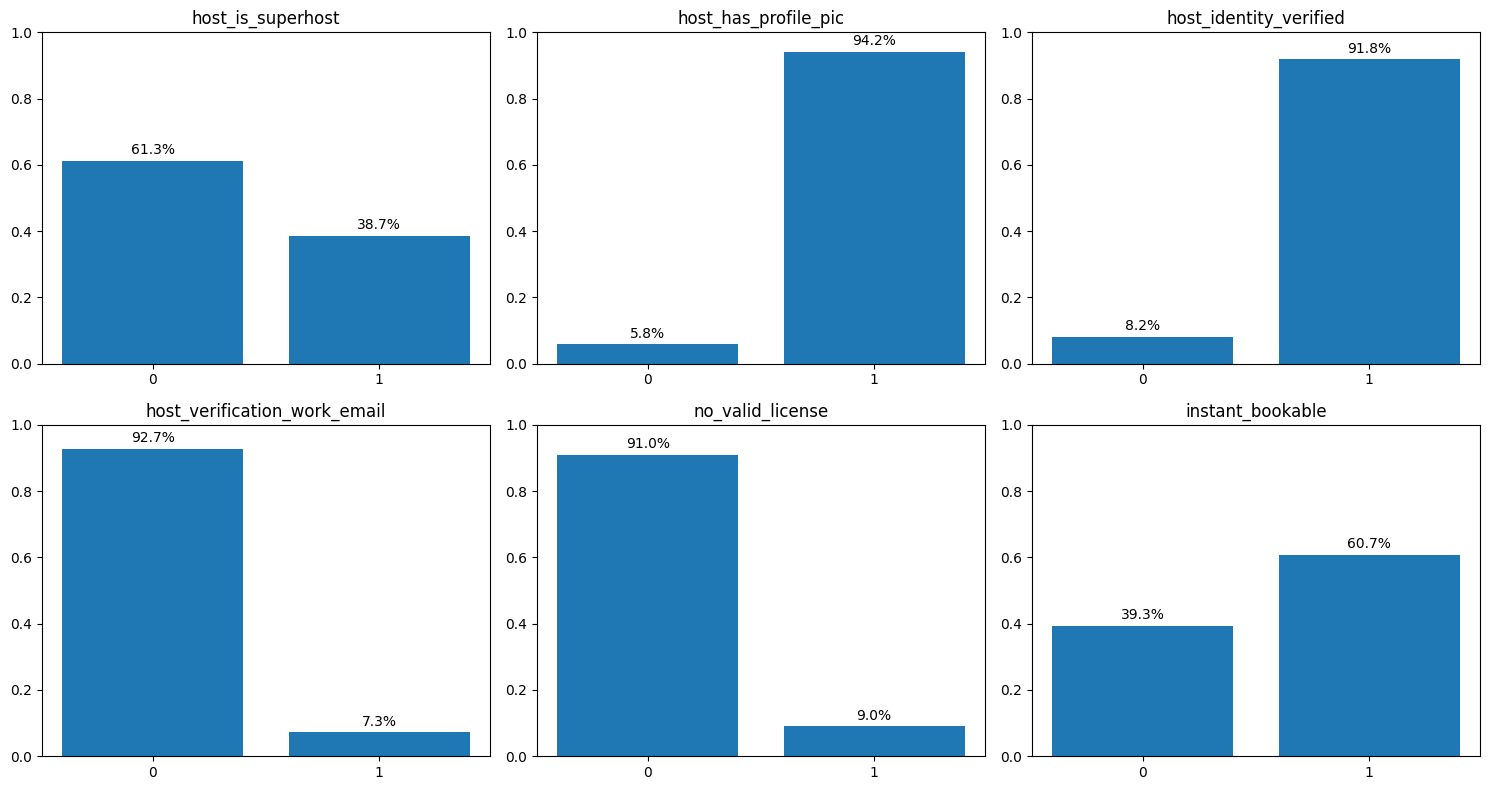

In [50]:
host_info_cols = ['host_is_superhost'
                  , 'host_has_profile_pic'
                  , 'host_identity_verified'
                  , 'host_verification_work_email'
                  , 'no_valid_license'
                  , 'instant_bookable']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(host_info_cols):
    dist = listings_cleaned[col].value_counts(normalize=True).reindex([0, 1]).fillna(0)
    axes[i].bar(['0', '1'], dist.values)
    axes[i].set_title(col)
    axes[i].set_ylim(0, 1)

    for j, v in enumerate(dist.values):
        axes[i].text(
            j,
            v + 0.02,
            f"{v * 100:.1f}%",
            ha='center',
            fontsize=10
        )

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Observations**:
* **Near-homogeneous features (low variance)**

`host_has_profile_pic` and `host_identity_verified`  show extremely high prevalence across the dataset, indicating that basic identity and profile completeness requirements are almost universally satisfied among hosts.

These variables exhibit strong ceiling effects and very low variance. As a result, they are expected to provide limited discriminatory power for clustering-based segmentation, as they do not meaningfully differentiate between listings.

* **Sparse but high-signal features**

`host_verification_work_email` and `no_valid_license` capture rare but structurally meaningful signals despite their strong class imbalance. A verified work email is indicative of professional host management (e.g., agencies or commercial operators), while missing or invalid licensing information may reflect regulatory non-compliance or incomplete registration.

* **Balanced behavioral differentiators**

`instant_bookable` and `host_is_superhost` exhibit relatively balanced distributions and reflect meaningful differences in host behavior.

- Bath structure information

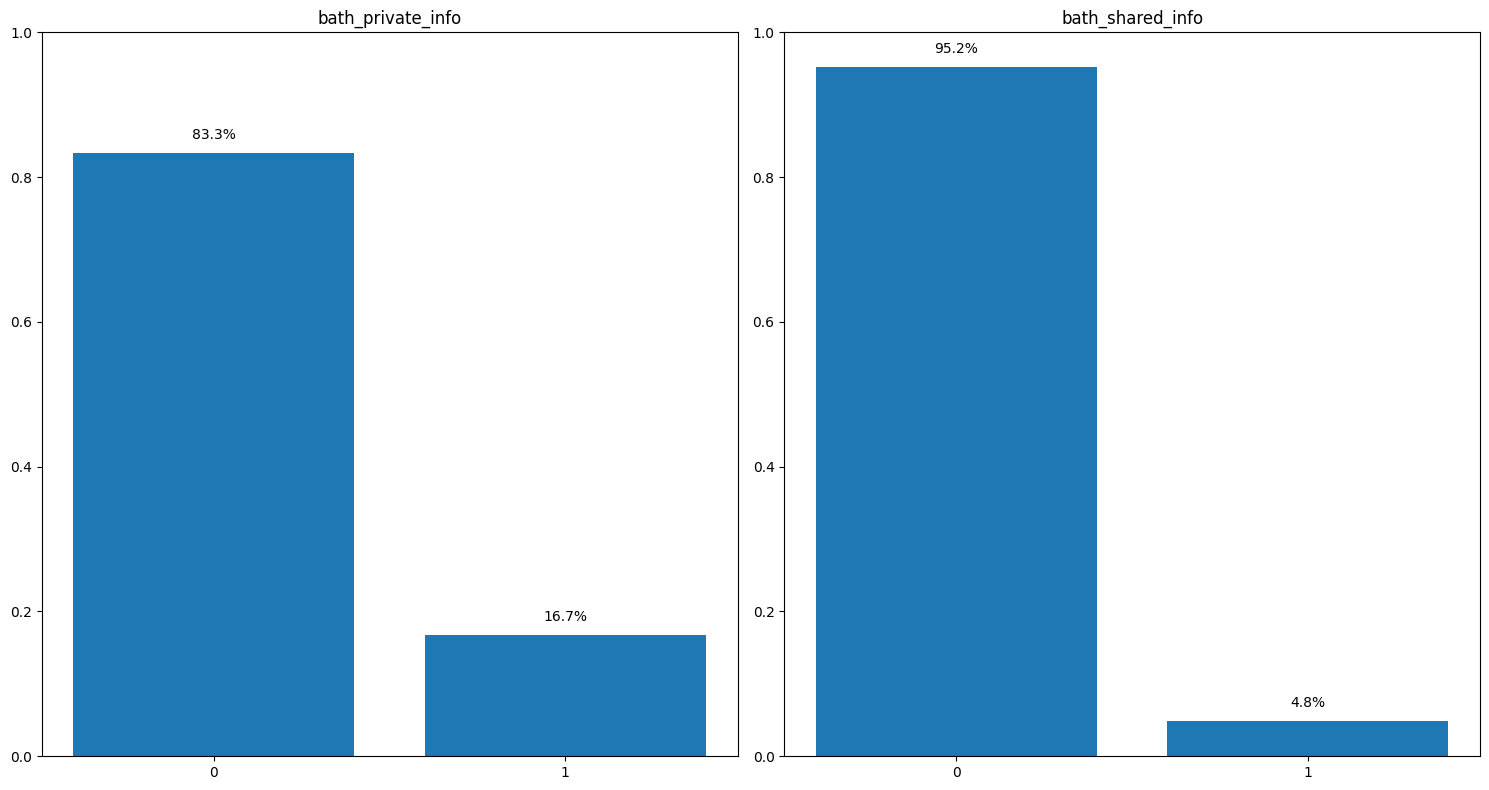

In [51]:
bath_cols = ['bath_private_info', 'bath_shared_info']

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(bath_cols):
    dist = listings_cleaned[col].value_counts(normalize=True).reindex([0, 1]).fillna(0)
    axes[i].bar(['0', '1'], dist.values)
    axes[i].set_title(col)
    axes[i].set_ylim(0, 1)

    for j, v in enumerate(dist.values):
        axes[i].text(
            j,
            v + 0.02,
            f"{v * 100:.1f}%",
            ha='center',
            fontsize=10
        )

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Observations:**
* **Explicit shared bathrooms**

`bath_shared_info` is present in only a very small fraction of listings, indicating that explicitly shared bathroom configurations are relatively rare in the dataset. Despite its low frequency, this is a high-signal structural feature and likely represents a strong downward pricing driver and is expected to concentrate within budget-oriented segments such as private rooms, shared accommodations, or hostel-like listings

* **Explicit private bathrooms**

`bath_private_info` appears in a relatively small subset of listings and is likely to be a weaker pricing driver compared to the `bath_shared_info` columns.

- Amenities

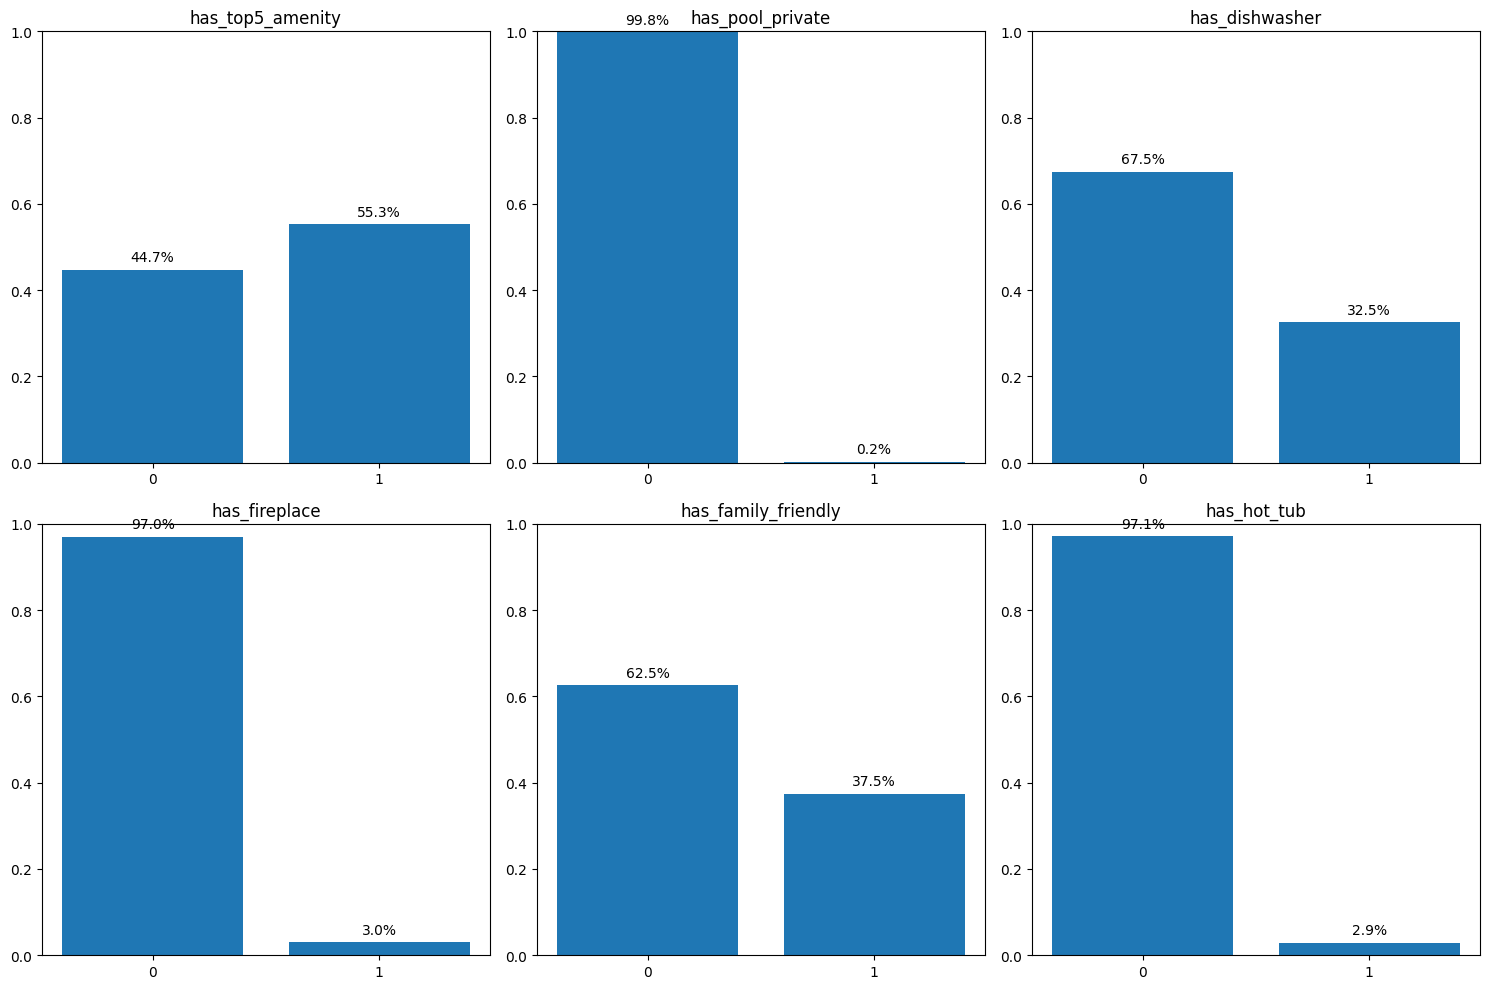

In [52]:
amenities_cols = ['has_top5_amenity', 'has_pool_private', 'has_dishwasher'
                  , 'has_fireplace', 'has_family_friendly', 'has_hot_tub']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(amenities_cols):
    dist = listings_cleaned[col].value_counts(normalize=True).reindex([0, 1]).fillna(0)
    axes[i].bar(['0', '1'], dist.values)
    axes[i].set_title(col)
    axes[i].set_ylim(0, 1)

    for j, v in enumerate(dist.values):
        axes[i].text(
            j,
            v + 0.02,
            f"{v * 100:.1f}%",
            ha='center',
            fontsize=10
        )

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Observations:**
- `has_top5_amenity` shows a relatively balanced distribution, with slightly more than half of listings containing at least one of the top five price-correlated amenities. This variable captures a meaningful mid-level quality threshold within the market

- `has_family_friendly` and `has_dishwasher` exhibit moderate prevalence and represent distinct dimensions of functional and demographic targeting within the market. Family-oriented amenities and household infrastructure are indicative of higher-quality residential setups and larger, more stable accommodation units.

- `has_fireplace`, `has_hot_tub` and `has_pool_private` are extremely rare in the dataset, but those variables  carry disproportionate semantic importance. They are strong markers of the ultra-luxury and exclusive segment of the market.